In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [3]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss


def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64)

100%|██████████| 170M/170M [00:38<00:00, 4.37MB/s] 


In [6]:
def plot_gates(model):
    all_gates = []

    for module in model.modules():
        if hasattr(module, "gate_scores"):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.figure()
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

In [7]:
def train_model(lambda_val):
    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 5

    for epoch in range(epochs):
        model.train()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            cls_loss = F.cross_entropy(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = cls_loss + lambda_val * sp_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}/{epochs} done")

    acc = evaluate(model, testloader, device)
    sparsity = calculate_sparsity(model)

    return acc, sparsity, model

In [8]:
lambdas = [1e-5, 1e-4, 1e-3]

results = []
best_model = None
best_acc = 0

for lam in lambdas:
    print(f"\n🚀 Training with lambda = {lam}")

    acc, sparsity, model = train_model(lam)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity))

    if acc > best_acc:
        best_acc = acc
        best_model = model


🚀 Training with lambda = 1e-05
Epoch 1/5 done
Epoch 2/5 done
Epoch 3/5 done
Epoch 4/5 done
Epoch 5/5 done
Accuracy: 46.50%
Sparsity: 1.15%

🚀 Training with lambda = 0.0001
Epoch 1/5 done
Epoch 2/5 done
Epoch 3/5 done
Epoch 4/5 done
Epoch 5/5 done
Accuracy: 45.32%
Sparsity: 1.57%

🚀 Training with lambda = 0.001
Epoch 1/5 done
Epoch 2/5 done
Epoch 3/5 done
Epoch 4/5 done
Epoch 5/5 done
Accuracy: 41.34%
Sparsity: 1.70%


In [9]:
print("\n📊 Final Results:")
for r in results:
    print(f"Lambda={r[0]} | Accuracy={r[1]:.2f}% | Sparsity={r[2]:.2f}%")


📊 Final Results:
Lambda=1e-05 | Accuracy=46.50% | Sparsity=1.15%
Lambda=0.0001 | Accuracy=45.32% | Sparsity=1.57%
Lambda=0.001 | Accuracy=41.34% | Sparsity=1.70%



📈 Plotting gate distribution...


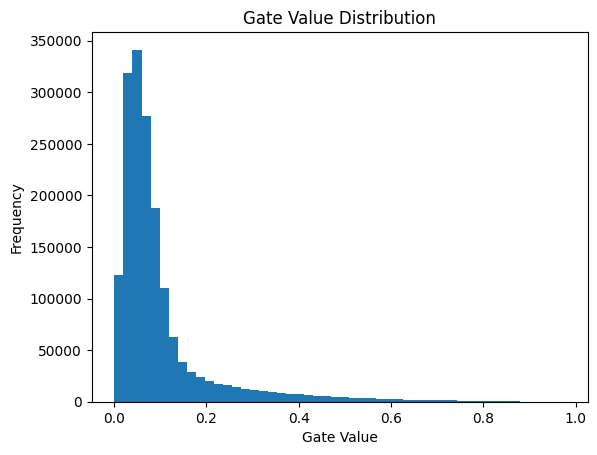

In [10]:
print("\n📈 Plotting gate distribution...")
plot_gates(best_model)